### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons: less expensive restaurants (under 20), coffee houses, carry out & take away, bar, and more expensive restaurants (20 - 50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8

    
2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)

3. Coupon attributes
    - time before it expires: 2 hours or one day

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [137]:
data = pd.read_csv('data/coupons.csv')

In [138]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [139]:
# Checking for missing values and sorting them from highest to lowest
missing_data = data.isnull().sum().sort_values(ascending=False)

print(missing_data)

car                     12576
CoffeeHouse               217
Restaurant20To50          189
CarryAway                 151
RestaurantLessThan20      130
Bar                       107
destination                 0
passanger                   0
direction_opp               0
direction_same              0
toCoupon_GEQ25min           0
toCoupon_GEQ15min           0
toCoupon_GEQ5min            0
income                      0
occupation                  0
education                   0
has_children                0
maritalStatus               0
age                         0
gender                      0
expiration                  0
coupon                      0
time                        0
temperature                 0
weather                     0
Y                           0
dtype: int64


In [140]:
data.shape

(12684, 26)

In [141]:
# Calculating the % of missing data for categories with missing data
print(f"% of missing data for car = {(data['car'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for CoffeeHouse = {(data['CoffeeHouse'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for Restaurant20To50 = {(data['Restaurant20To50'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for CarryAway = {(data['CarryAway'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for RestaurantLessThan20 = {(data['RestaurantLessThan20'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for Bar = {(data['Bar'].isnull().sum() / data.shape[0]) * 100:.2f}%")

% of missing data for car = 99.15%
% of missing data for CoffeeHouse = 1.71%
% of missing data for Restaurant20To50 = 1.49%
% of missing data for CarryAway = 1.19%
% of missing data for RestaurantLessThan20 = 1.02%
% of missing data for Bar = 0.84%


3. Decide what to do about your missing data -- drop, replace, other...

## Based on the % of missing data:
######
###### Percent of missing data for car = 99.15%
###### Percent of missing data for CoffeeHouse = 1.71% 
###### Percent of missing data for Restaurant20To50 = 1.49%
###### Percent of missing data for CarryAway = 1.19%
###### Percent of missing data for RestaurantLessThan20 = 1.02%
###### Percent of missing data for Bar = 0.84%
######
### DECISION
#### - Missing data in car column is too high (> 20%); will drop this column
#### - As for the rest of the columns, the % of missing data is < 2% per category, will proceed to fill with the mode

In [142]:
# Dropping the "car" column
print(f"Size of the DataFrame before dropping the column car: ", data.shape)

data = data.drop(columns=['car'])

# Verifying the column was dropped correctly 
print("car" in data.columns) # I would expect to see "False"
print(f"Size of the DataFrame after dropping the column car: ", data.shape)
data.head()

Size of the DataFrame before dropping the column car:  (12684, 26)
False
Size of the DataFrame after dropping the column car:  (12684, 25)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [143]:
# List of columns to fix
columns_to_fix = ["CoffeeHouse", "Restaurant20To50", "CarryAway", "RestaurantLessThan20", "Bar"]

# Fill each column with the mode
for col in columns_to_fix:
    data[col] = data[col].fillna(data[col].mode()[0])

# Verify all missing data has been filled or removed from the dataset
missing_data_new = data.isnull().sum().sort_values(ascending=False)

print(missing_data_new)

destination             0
income                  0
direction_opp           0
direction_same          0
toCoupon_GEQ25min       0
toCoupon_GEQ15min       0
toCoupon_GEQ5min        0
Restaurant20To50        0
RestaurantLessThan20    0
CarryAway               0
CoffeeHouse             0
Bar                     0
occupation              0
passanger               0
education               0
has_children            0
maritalStatus           0
age                     0
gender                  0
expiration              0
coupon                  0
time                    0
temperature             0
weather                 0
Y                       0
dtype: int64


In [144]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  Bar                   12684 non-null  object
 15  CoffeeHouse           12684 non-null

In [145]:
# Checking for problematic values
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [146]:
# Checking for bad values in all columns
bad_values = ["Unknown", "N/A", "?", "None"]

data.isin(bad_values).sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

### OBSERVATION: Data does not contain any bad values like: Unknown, N/A, ? or None

In [147]:
# checking for duplicates
data.duplicated().sum()

np.int64(74)

In [148]:
# Inspecting the duplciates
data[data.duplicated(keep=False)]

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
4191,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,less1,less1,1,1,1,0,1,1
4192,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,less1,less1,1,1,1,0,1,1
4235,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,gt8,gt8,4~8,less1,1,1,1,0,1,1
4236,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,gt8,gt8,4~8,less1,1,1,1,0,1,1
4279,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,26,Single,...,never,4~8,1~3,less1,1,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8511,Home,Alone,Sunny,80,6PM,Bar,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,0,0,1,0,1
8512,Home,Partner,Sunny,30,10PM,Carry out & Take away,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,1
8513,Work,Alone,Rainy,55,7AM,Restaurant(<20),2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,1,0,1,0
8515,Work,Alone,Snowy,30,7AM,Restaurant(20-50),1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,1,0,1,0


### OBSERVATION 
#### It is hard to determine whether these 74 rows are indeed real duplicats as it could be different people having a similar profiles, however, 74 rows with duplicates out of 12,684 only represents 0.58% of the data. If I were to feed this data into a ML algorithm, my recommendation would be to drop the duplicates for a cleaner dataset and to prevent overfitting

In [149]:
print(f"Size of the DataFrame before dropping the duplicates: ", data.shape)

# Remove the 74 duplicate rows
data.drop_duplicates(inplace=True)

print(f"Size of the DataFrame after dropping the duplicates: ", data.shape)

Size of the DataFrame before dropping the duplicates:  (12684, 25)
Size of the DataFrame after dropping the duplicates:  (12610, 25)


In [150]:
# The last check before I move to the next section is to look for any "logically imposible" values like: 
# GEQ25min = 1 but GEQ15min = 0

# Check1
error_25_15 = data[(data["toCoupon_GEQ25min"] == 1) & (data["toCoupon_GEQ15min"] == 0)]

# Check2
error_25_5 = data[(data["toCoupon_GEQ25min"] == 1) & (data["toCoupon_GEQ5min"] == 0)]

# Check3
error_15_5 = data[(data["toCoupon_GEQ15min"] == 1) & (data["toCoupon_GEQ5min"] == 0)]

print(f"Errors (25min > 15min): {len(error_25_15)}")
print(f"Errors (25min > 5min): {len(error_25_5)}")
print(f"Errors (15min > 5min): {len(error_15_5)}")

Errors (25min > 15min): 0
Errors (25min > 5min): 0
Errors (15min > 5min): 0


### NO logical errors found

4. What proportion of the total observations chose to accept the coupon?



In [151]:
# Since Y contains binary values, calculating the % of ones and zeros 
coupon_acceptance_rate = data["Y"].value_counts(normalize=True) * 100

print(coupon_acceptance_rate)

Y
1    56.756542
0    43.243458
Name: proportion, dtype: float64


5. Use a bar plot to visualize the `coupon` column.

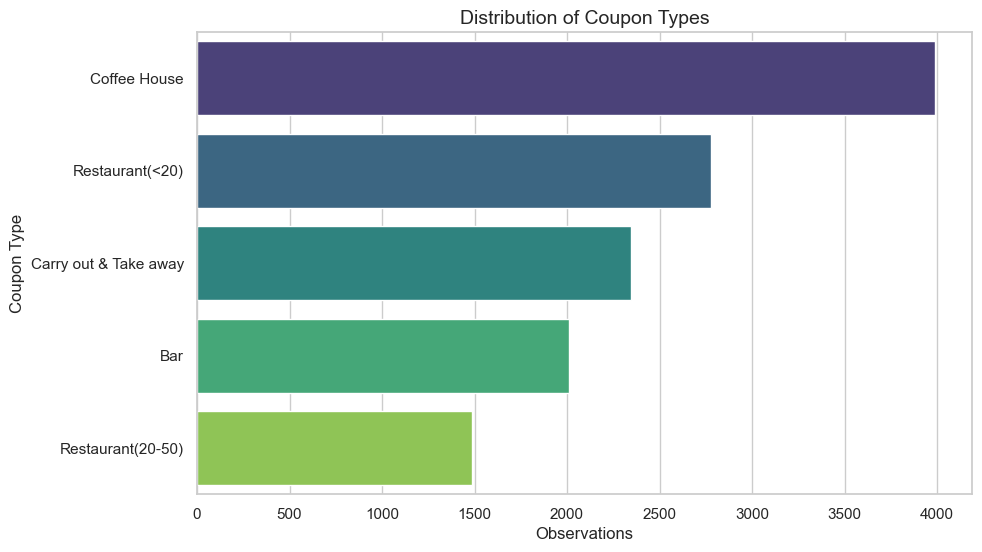

In [152]:
plt.figure(figsize = (10, 6))
sns.set_theme(style = "whitegrid")

coupon_counts = data["coupon"].value_counts().sort_values(ascending=False)

# Creating the plot after playing around with a few Palette options
sns.barplot(x = coupon_counts.values, y = coupon_counts.index, hue = coupon_counts.index, palette="viridis", legend=False)

plt.title("Distribution of Coupon Types", fontsize=14)
plt.xlabel("Observations", fontsize=12)
plt.ylabel("Coupon Type", fontsize=12)

# Saving the plot
plt.savefig("images/barplot1.png")

plt.show()

6. Use a histogram to visualize the temperature column.

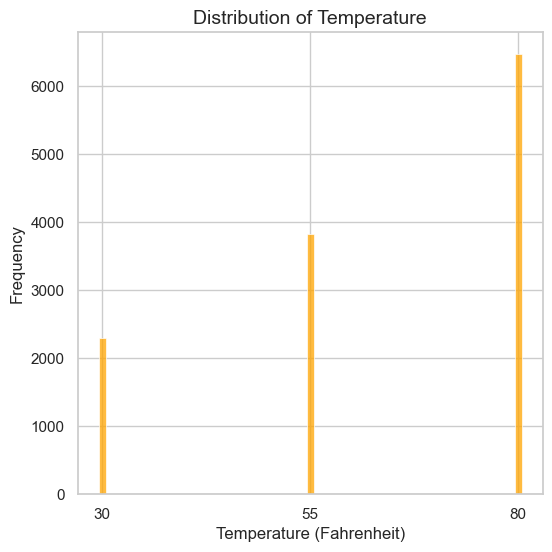

In [153]:
plt.figure(figsize = (6, 6))
sns.set_theme(style = "whitegrid")

# Creating the histogram
sns.histplot(data["temperature"], discrete=True, color="orange", shrink=0.8)

plt.title("Distribution of Temperature", fontsize=14)
plt.xlabel("Temperature (Fahrenheit)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks([30, 55, 80])

# Saving the plot
plt.savefig("images/histo1.png")

plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [154]:
bar_df = data[data["coupon"] == "Bar"].copy()

In [155]:
bar_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


In [156]:
bar_df.shape

(2010, 25)

2. What proportion of bar coupons were accepted?


In [157]:
# Since Y contains binary values, calculating the % of ones and zeros for this new dataframe
bar_coupon_acceptance = bar_df['Y'].value_counts(normalize=True) * 100

print(bar_coupon_acceptance)

Y
0    59.004975
1    40.995025
Name: proportion, dtype: float64


### The portion of the bar coupons that were accepted = ~41%

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [158]:
# Creating the criteria for each group
frequent_cat = ["4~8", "gt8"]

# Creating the the target group
target_group = (bar_df["Bar"].isin(frequent_cat))

# Creating a new column to label the groups
bar_df.loc[target_group, "bar_freq_separation"] = "Bar goer > 3 times"
bar_df.loc[~target_group, "bar_freq_separation"] = "Bar goers 3 or fewer times"

# Calculate acceptance rate (Y)
first_analysis = bar_df.groupby("bar_freq_separation")["Y"].mean() * 100

print(first_analysis)

bar_freq_separation
Bar goer > 3 times            76.884422
Bar goers 3 or fewer times    37.051353
Name: Y, dtype: float64


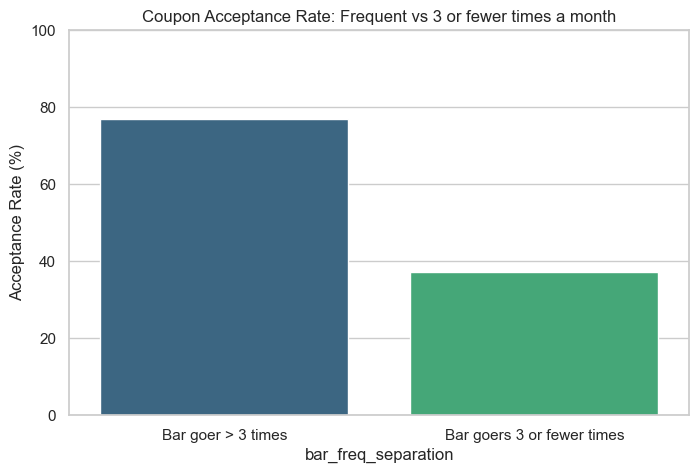

In [159]:
# Using a barplot to visualize the results / keeping the same palette for consistency 
plt.figure(figsize=(8, 5))
sns.barplot(x = first_analysis.index, y = first_analysis.values, hue = first_analysis.index, palette='viridis', legend=False)

plt.title("Coupon Acceptance Rate: Frequent vs 3 or fewer times a month")
plt.xticks([0, 1], ["Bar goer > 3 times", "Bar goers 3 or fewer times"])
plt.ylabel("Acceptance Rate (%)")
plt.ylim(0, 100) 

# Saving the plot
plt.savefig("images/barplot2.png")

plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


### The groups not meeting this criteria are: 
#### Bar: "never" and "less1"
#### Age: "below21" and "21"

In [160]:
# Creating the criteria for each group
frequent_cat = ["1~3", "4~8", "gt8"]
over_25 = ["26", "31", "36", "41", "46", "50plus"]

# Creating the the target group
target_group = (bar_df["Bar"].isin(frequent_cat)) & (bar_df["age"].isin(over_25))

# Creating a new column to label the groups
bar_df.loc[target_group, "bar_age_separation"] = "Frequent bar goer > 25"
bar_df.loc[~target_group, "bar_age_separation"] = "All Other"

# Calculate acceptance rate (Y)
analysis = bar_df.groupby("bar_age_separation")["Y"].mean() * 100

print(analysis)

bar_age_separation
All Other                 33.459119
Frequent bar goer > 25    69.523810
Name: Y, dtype: float64


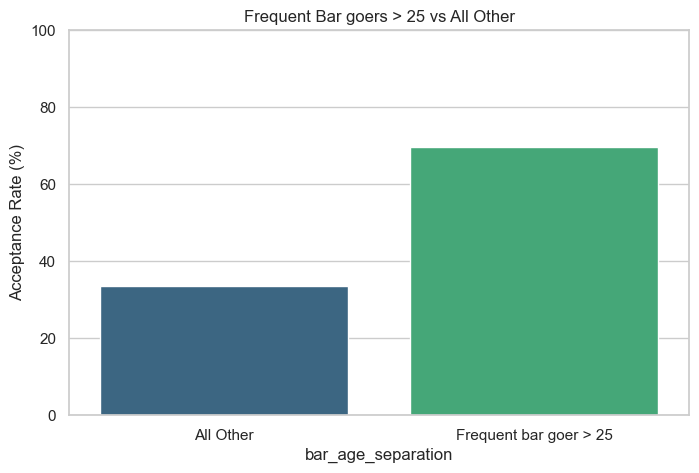

In [161]:
# Using a barplot to visualize the results / keeping the same palette for consistency 
plt.figure(figsize=(8, 5))
sns.barplot(x = analysis.index, y = analysis.values, hue = analysis.index, palette='viridis', legend=False)

plt.title("Frequent Bar goers > 25 vs All Other")
plt.xticks([0, 1], ["All Other", "Frequent bar goer > 25"])
plt.ylabel("Acceptance Rate (%)")
plt.ylim(0, 100) 

# Saving the plot
plt.savefig("images/barplot3.png")

plt.show()

### To answer the question: Is there a difference?
#### The answer is yes, the "Frequent bar-goer > 25" group is more than twice as likely to accept a bar coupon than the rest of the population (69.5% vs 33.4%)

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [162]:
# Defining filter criterias
frequent_bar = ["1~3", "4~8", "gt8"]  # Frequent bar more than once a month
non_kid_passengers = ["Friend(s)", "Partner"] # Passengers are not kids
excluded_occupation = "Farming Fishing & Forestry" # excluded_occupation

# Create the target dataset
target_dataset = ((bar_df["Bar"].isin(frequent_bar)) & (bar_df["passanger"].isin(non_kid_passengers)) & (bar_df["occupation"] != excluded_occupation))

bar_df.loc[target_dataset, "special_segment"] = 'Target Group'
bar_df.loc[~target_dataset, "special_segment"] = 'All Others'

# Calculating the acceptance rates
segment_analysis = bar_df.groupby("special_segment")["Y"].mean() * 100

print(segment_analysis)

special_segment
All Others      37.685950
Target Group    71.794872
Name: Y, dtype: float64


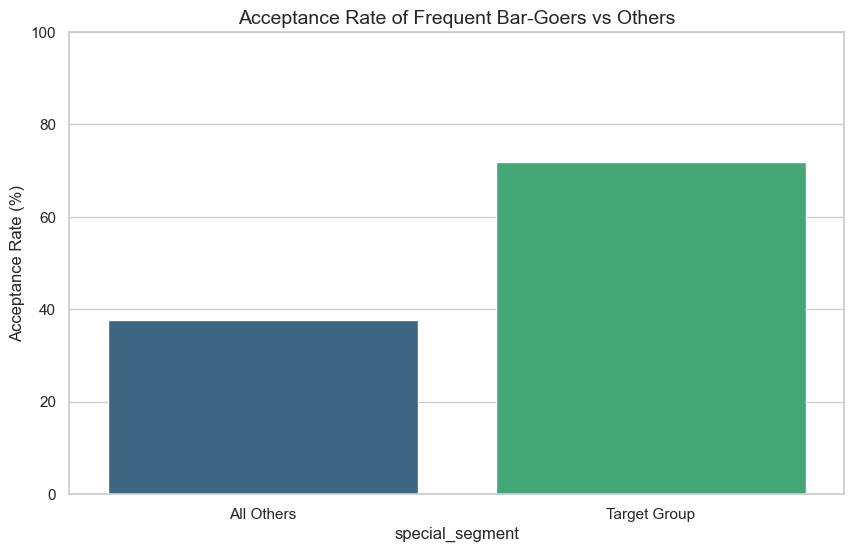

In [163]:
plt.figure(figsize=(10, 6))
sns.set_theme(style = "whitegrid")

# Plotting the results
sns.barplot(x = segment_analysis.index, y = segment_analysis.values, hue = segment_analysis.index, palette='viridis', legend=False)

plt.title("Acceptance Rate of Frequent Bar-Goers vs Others", fontsize=14)
plt.ylabel('Acceptance Rate (%)')
plt.ylim(0, 100)

# Saving the plot
plt.savefig("images/barplot4.png")

plt.show()

### OBSERVATION: Drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry has a high acceptance rate (~71.7%)

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [164]:
# Defining the different filter categories
frequent_bar = ["1~3", "4~8", "gt8"] # Visit bars more than once a month
frequent_cheap_rest = ["4~8", "gt8"] # go to cheap restaurants more than 4 times a month
non_kid_passengers = ["Friend(s)", "Partner"] # had passengers that were not a kid
under_30 = ["below21", "21", "26"] # group under the age of 30
low_income = ["Less than $12,500", "$12,500 - $24,999", "$25,000 - $37,499", "$37,500 - $49,999"] #  income is less than 50K

# Filtering for Condition #1: go to bars more than once a month, had passengers that were not a kid, and were not widowed 
cond1 = (bar_df["Bar"].isin(frequent_bar)) & (bar_df["passanger"].isin(non_kid_passengers)) & (bar_df["maritalStatus"] != "Widowed")

# Filtering for Condition #2: go to bars more than once a month and are under the age of 30
cond2 = (bar_df["Bar"].isin(frequent_bar)) & (bar_df["age"].isin(under_30))

# Filtering for Condition #3: go to cheap restaurants more than 4 times a month and income is less than 50K
cond3 = (bar_df["RestaurantLessThan20"].isin(frequent_cheap_rest)) & (bar_df["income"].isin(low_income))

# Creating a group with an OR that meet all the criterias
final_cond = cond1 | cond2 | cond3

bar_df.loc[final_cond, "group_type"] = "Target Group"
bar_df.loc[~final_cond, "group_type"] = "All Others"

final_analysis = bar_df.groupby("group_type")["Y"].mean() * 100
print(final_analysis)

group_type
All Others      33.017677
Target Group    70.657277
Name: Y, dtype: float64


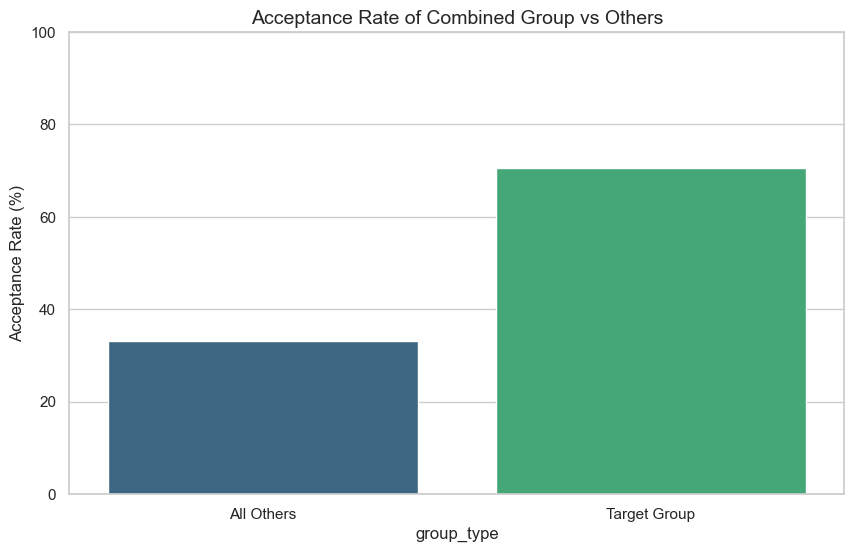

In [165]:
plt.figure(figsize=(10, 6))
sns.set_theme(style = "whitegrid")

# Plotting the results
sns.barplot(x = final_analysis.index, y = final_analysis.values, hue = final_analysis.index, palette='viridis', legend=False)

plt.title("Acceptance Rate of Combined Group vs Others", fontsize=14)
plt.ylabel('Acceptance Rate (%)')
plt.ylim(0, 100)

# Saving the plot
plt.savefig("images/barplot5.png")

plt.show()

#### OBSERVATION: Drivers who:
#### go to bars more than once a month, had passengers that were not a kid, and were not widowed OR
#### go to bars more than once a month and are under the age of 30 OR
#### go to cheap restaurants more than 4 times a month and income is less than 50K
#### tend to have higher acceptance rates than other groups

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

### CONCLUSION: Based on this data, drivers older than 25 y/o who drive w/o kids and frequent cheaper restaurants are likely to accept bar coupons when the offer aligns with their existing social habit rather than just being a random discount for a new experience

# Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [166]:
# For this additional investigation I will focus now on the "Coffee House" coupon category
# Using the data dataFrame as this has been cleanned already

coffee_df = data[data["coupon"] == "Coffee House"].copy()

In [167]:
coffee_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0


In [168]:
coffee_df.shape

(3989, 25)

In [169]:
# Calculating the acceptance rate
coffee_coupon_acceptance = coffee_df["Y"].value_counts(normalize=True) * 100

print(coffee_coupon_acceptance)

Y
0    50.137879
1    49.862121
Name: proportion, dtype: float64


### OBSERVATION: The overall acceptance rate for a coffee coupon is almost even (50/50 %)

### Investigating the weather impact by gender

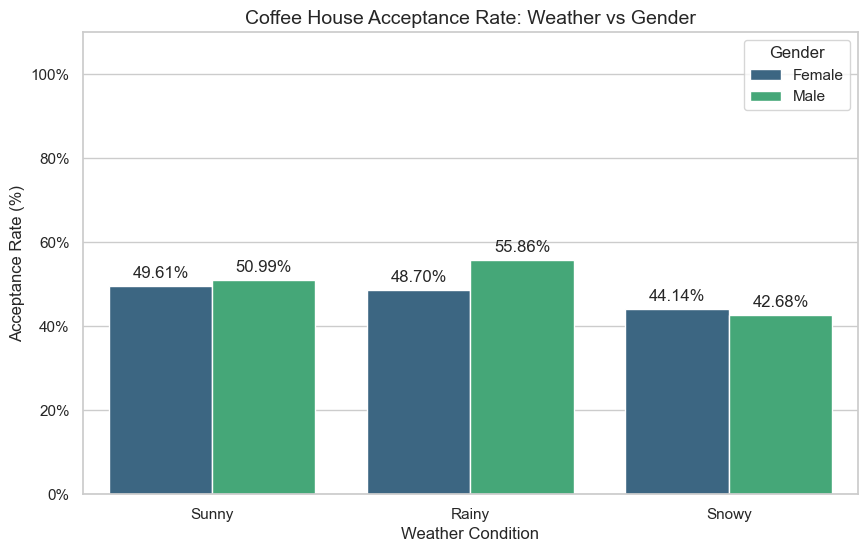

In [170]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 6))

# Generating a bar plot
plot1 = sns.barplot(data = coffee_df, x = "weather", y = "Y", hue = "gender", palette = "viridis", errorbar=None)

# Formatting the Y-axis to % -- I JUST LEARNED THIS LINE OF CODE :)
plot1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Adding % labels on top of each bar
for p in plot1.patches:
    if p.get_height() > 0: 
        plot1.annotate(f"{p.get_height()*100:.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha = "center", va = "center", xytext=(0, 9), textcoords = "offset points")

plt.title("Coffee House Acceptance Rate: Weather vs Gender", fontsize=14)
plt.ylabel("Acceptance Rate (%)")
plt.xlabel("Weather Condition")
plt.ylim(0, 1.1)
plt.legend(title = "Gender")

# Saving the plot
plt.savefig("images/barplot6.png")

plt.show()

### Investigating the time of day impact by gender

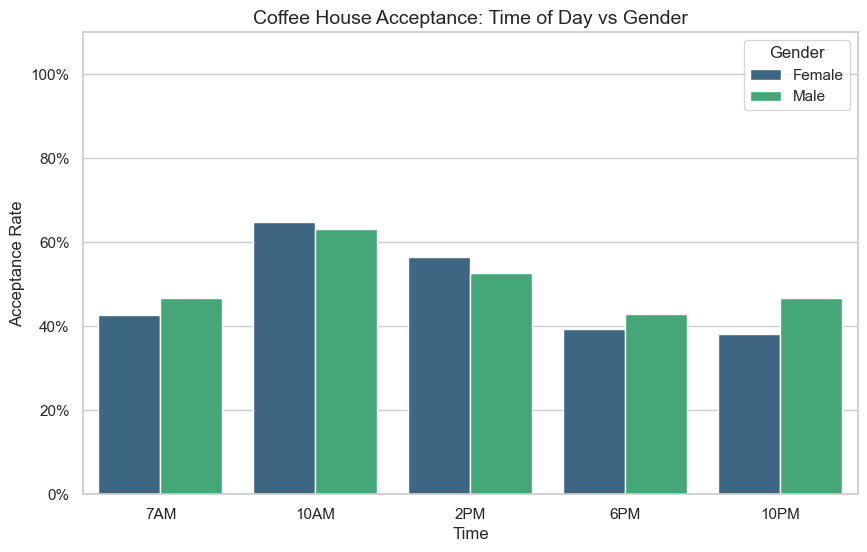

In [171]:
plt.figure(figsize=(10, 6))

time_order = ["7AM", "10AM", "2PM", "6PM", "10PM"]

plot2 = sns.barplot(data = coffee_df, x = "time", y = "Y", hue = "gender", order = time_order, palette="viridis", errorbar=None)

# Formatting the Y-axis to % -- I JUST LEARNED THIS LINE OF CODE :)
plot2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Adding % labels on top of each bar
for p in plot2.patches:
    if p.get_height() > 0: 
        plot1.annotate(f"{p.get_height()*100:.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha = "center", va = "center", xytext=(0, 9), textcoords = "offset points")

plt.title("Coffee House Acceptance: Time of Day vs Gender", fontsize=14)
plt.ylabel("Acceptance Rate")
plt.xlabel("Time")
plt.ylim(0, 1.1)
plt.legend(title = "Gender")

# Saving the plot
plt.savefig("images/barplot7.png")

plt.show()

### From plot above, 10AM and 2PM are the times with the highest acceptance rate, therefore will now be comparing if there is any trend wrt coupon expiration for these 2 times

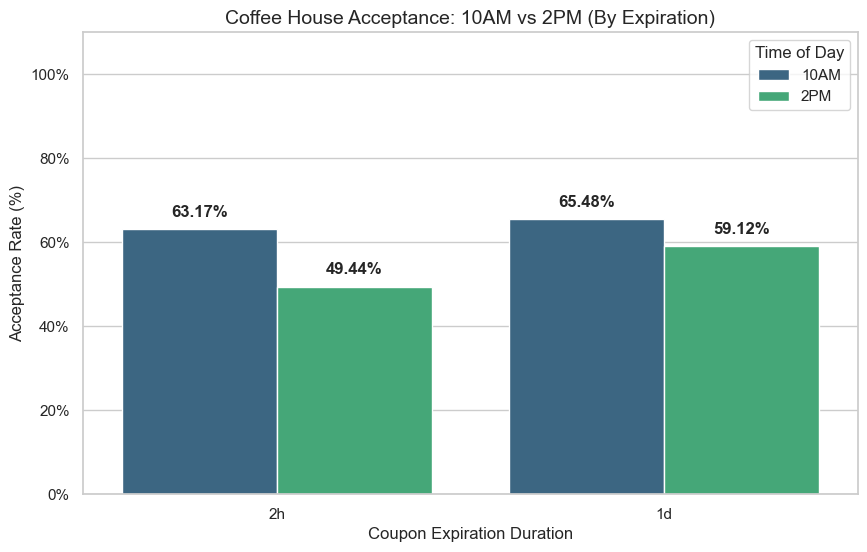

In [172]:
# 1. Filter for Coffee House coupons AND specific times
# We use .isin() to catch both 10AM and 2PM
peak_coffee_df = coffee_df[coffee_df["time"].isin(["10AM", "2PM"])].copy()

plt.figure(figsize=(10, 6))

plot3 = sns.barplot(data = peak_coffee_df, x = "expiration", y = "Y", hue = "time", palette = "viridis", errorbar=None)

plot3.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Adding % labels to bars
for p in plot3.patches:
    if p.get_height() > 0:
        plot3.annotate(f"{p.get_height()*100:.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha = "center", va = "center", xytext = (0, 12), textcoords = "offset points", fontweight = "bold")

# Adding title and labels to each axis
plt.title("Coffee House Acceptance: 10AM vs 2PM (By Expiration)", fontsize=14)
plt.ylabel("Acceptance Rate (%)")
plt.xlabel("Coupon Expiration Duration")
plt.ylim(0, 1.1)
plt.legend(title = "Time of Day")

# Saving the plot
plt.savefig("images/barplot8.png")

plt.show()

### Exploring trends wrt Destination and Occupation

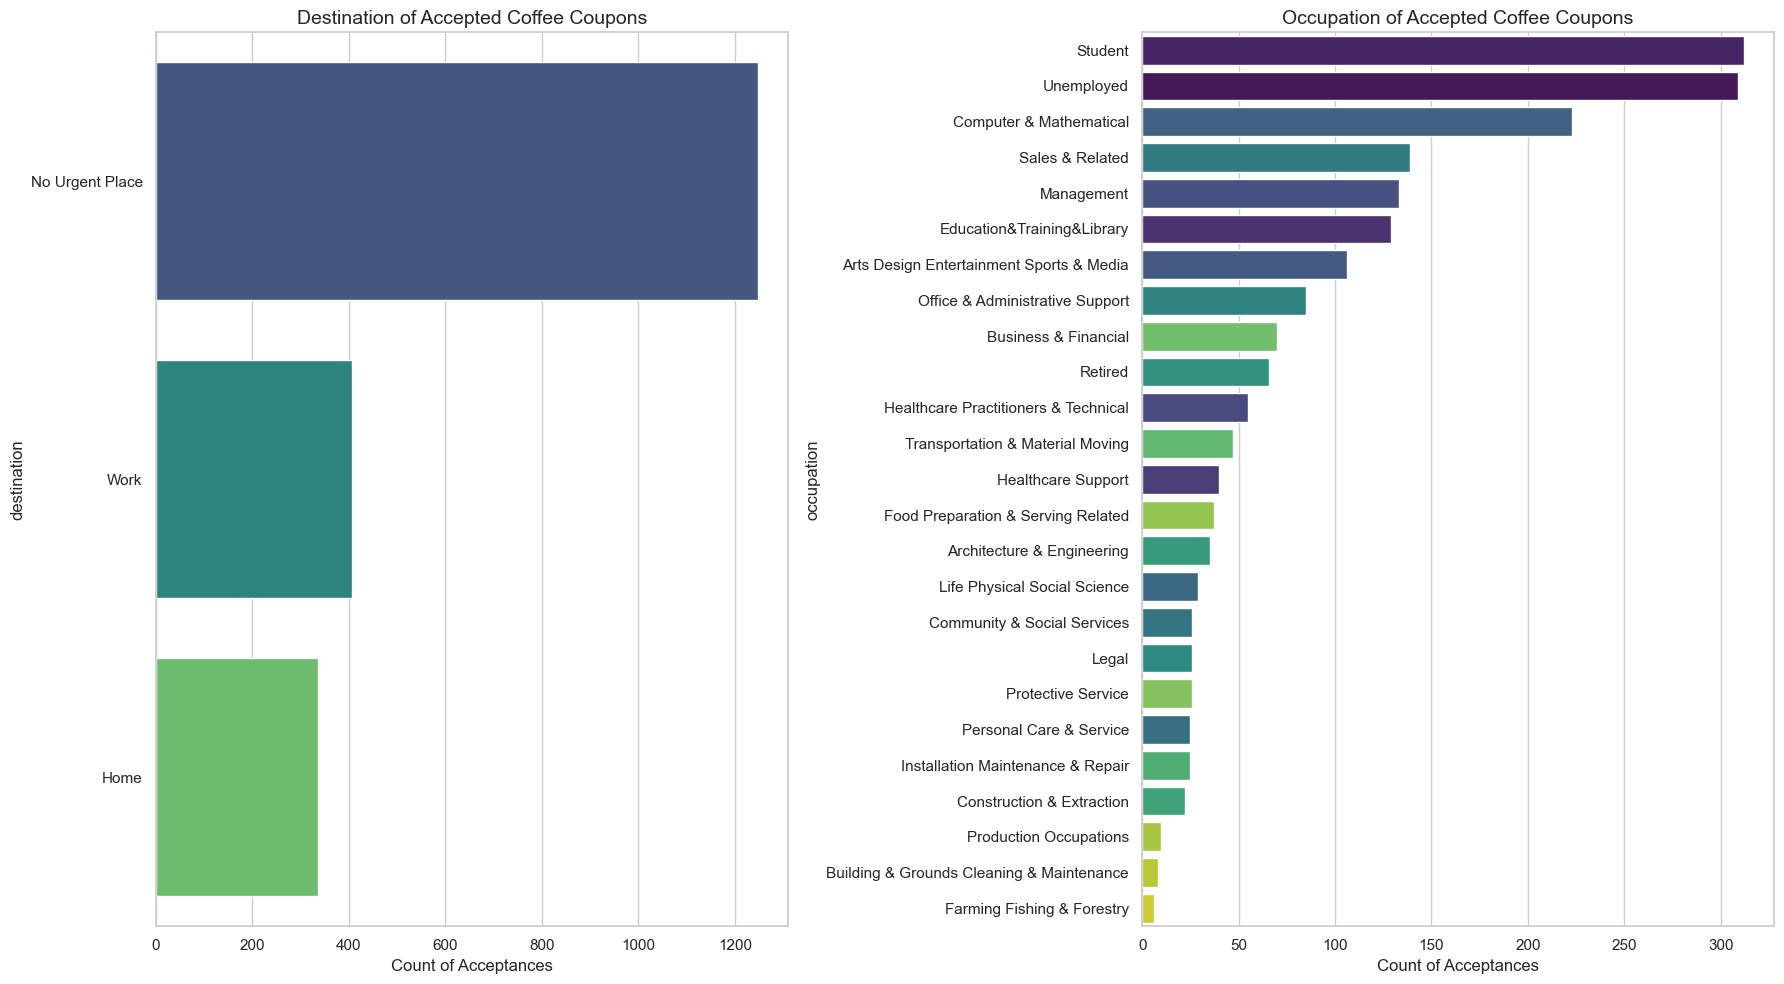

In [173]:
# Filtering coffee_df for only those who accepted the coupon (Y = 1)
accepted_coffee_df = coffee_df[coffee_df["Y"] == 1].copy()

# Setting up a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Plot #1: Destination of those who accepted the coupon
sns.countplot(data = accepted_coffee_df, y = "destination", ax = axes[0], palette = "viridis", hue = "destination", legend = False)
axes[0].set_title("Destination of Accepted Coffee Coupons", fontsize=14)
axes[0].set_xlabel("Count of Acceptances")

# Plot #2: Occupation of those who accepted the coupon
occupation_order = accepted_coffee_df["occupation"].value_counts().index

sns.countplot(data = accepted_coffee_df, y = "occupation", ax = axes[1], palette = "viridis", order = occupation_order, hue = "occupation", legend = False)
axes[1].set_title("Occupation of Accepted Coffee Coupons", fontsize=14)
axes[1].set_xlabel("Count of Acceptances")

# Saving the plot
plt.savefig("images/subplot1.png")

plt.tight_layout()
plt.show()

### Taking a look at Coffee House Acceptance: Age vs. Income

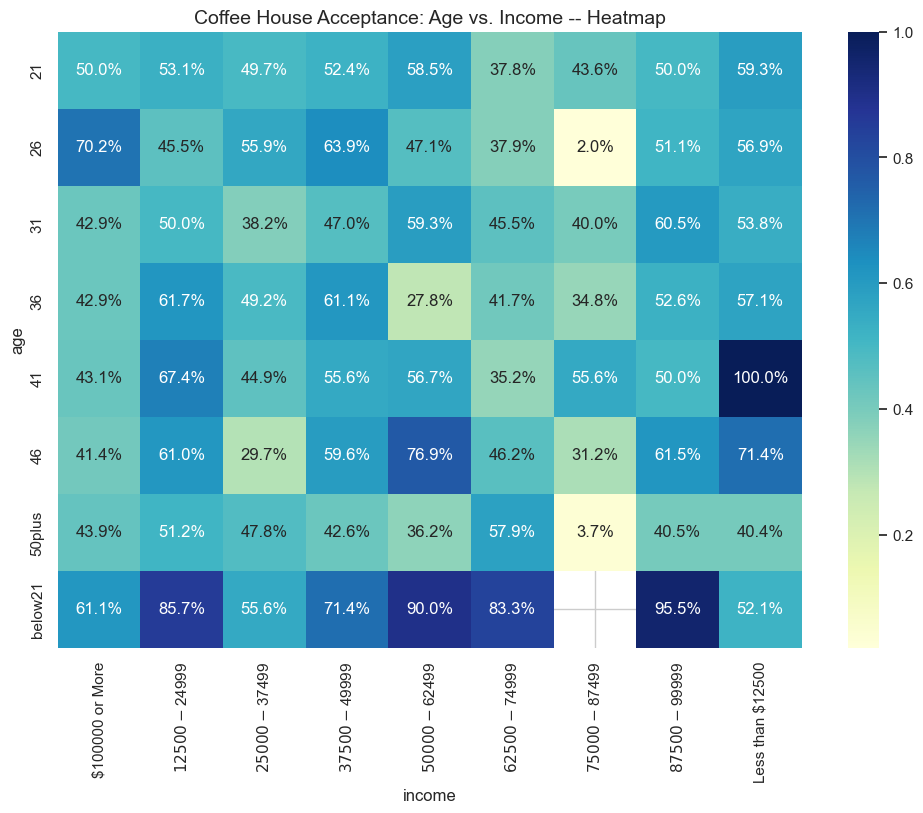

In [174]:
# Preparing the data: Acceptance Rate by Age and Income
pivot_df = coffee_df.groupby(["age", "income"])["Y"].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot = True, fmt = ".1%", cmap = "YlGnBu")
plt.title("Coffee House Acceptance: Age vs. Income -- Heatmap", fontsize=14)

# Saving the plot
plt.savefig("images/heatplot1.png")

plt.show()

### Taking a look at the impact of having children in Coffee House coupon acceptance

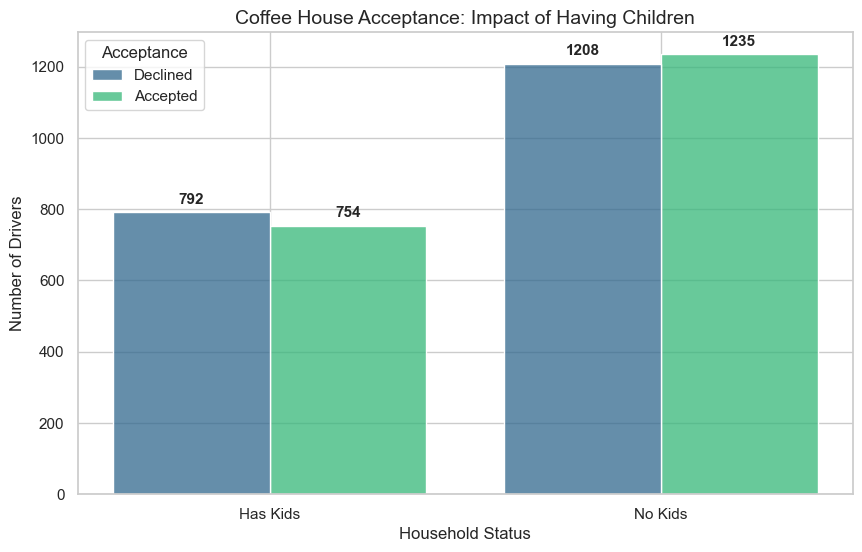

In [175]:
# Preparing the plot
plot_df = coffee_df.copy()
plot_df["Acceptance"] = plot_df["Y"].map({1: "Accepted", 0: "Declined"})
plot_df["Children"] = plot_df["has_children"].map({1: "Has Kids", 0: "No Kids"})

plt.figure(figsize=(10, 6))

plot4 = sns.histplot(data = plot_df, x = "Children", hue = "Acceptance", multiple = "dodge", shrink=0.8, palette = "viridis")

# # Adding % labels to bars
for p in plot4.patches:
    if p.get_height() > 0:
        plot4.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha = "center", va = "center", xytext=(0, 9), textcoords = "offset points", fontsize = 11, fontweight = "bold")

plt.title("Coffee House Acceptance: Impact of Having Children", fontsize=14)
plt.xlabel("Household Status", fontsize=12)
plt.ylabel("Number of Drivers", fontsize=12)

# Saving the plot
plt.savefig("images/histo2.png")

plt.show()

### Taking a look at the impact of age in Coffee House coupon acceptance

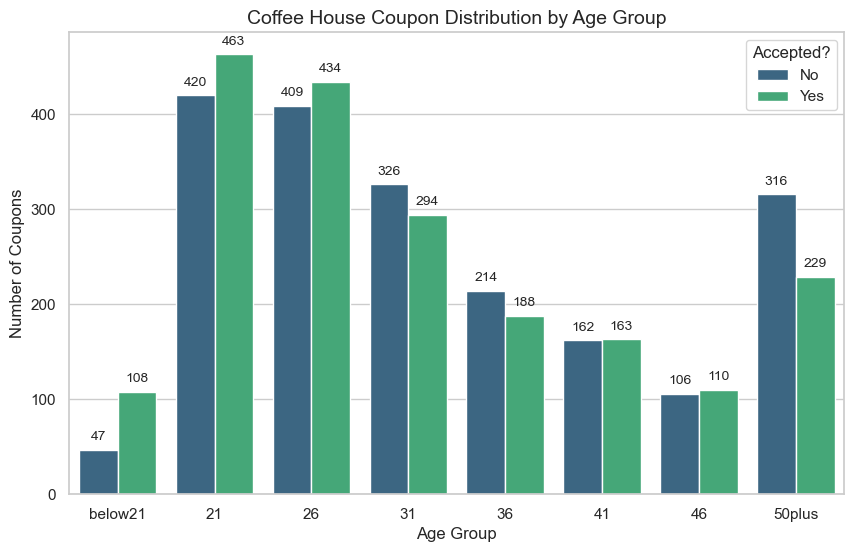

In [176]:
# Sorting age ascending
age_order = ["below21", "21", "26", "31", "36", "41", "46", "50plus"]

plt.figure(figsize=(10, 6))

plot5 = sns.countplot(data = coffee_df, x = "age", order = age_order, hue = "Y", palette = "viridis")

# 4. Adding labels on top of each bar for clarity
for p in plot5.patches:
    if p.get_height() > 0:
        plot5.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha = "center", va = "center", xytext = (0, 9), textcoords = "offset points", fontsize = 10)

plt.title("Coffee House Coupon Distribution by Age Group", fontsize=14)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Coupons", fontsize = 12)
plt.legend(title = "Accepted?", labels = ["No", "Yes"])

# Saving the plot
plt.savefig("images/countplot1.png")

plt.show()

# CONCLUSION
### I would have like to generate other type of plots like Box Plots and Scatter plots, however, it was not ideal because the data contained in this set is almost all categorical (i.e. text labels like "Sunny", "10AM", "Student"), therefore, scatter plots or histrograms would not have been very useful
### As of this "Independent Investigation", I found:
 - The overall acceptance rate for a coffee coupon is almost even (50/50 %)
 - There is a 5% higher higher acceptance rate on rainy days compared to sunny days, however, the smaller is during snowy days, probably because people prefer to stay home
 - The highest acceptance rate happens at 10am followed by 2pm. Seems like acceptance rate is not very high when it is too early or too late in the day
 - The acceptance rate for coffee house coupons at 10am is higher for coupons expiring in 2hrs or in 1 day, however, people tend to have a higher acceptance rate of coupons expiring the next day after 2pm
 - A subplot exploring trends wrt Destination and Occupation show some interesting facts:
     - The highest acceptance rate for Coffee House coupons comes from people who have “No Urgent Place” to go
     - Also, the highest acceptance rate for Coffee House coupons comes from either Students or Unemployed people followed by “Computer and Mathematical” occupation, which consequently, it is people below 21 y/o
 - Interestingly, the people who seem to consume more coffee are in the category of 21 and 26 y/o with a decrease as age increases until people get to 50+ y/o

### Next steps and recommendations
 - Each coupon code requires it's own analysis
 - It will be interesting to understand if there are other factos besides income that drive people to select cheap restaurants vs expensive restaurants
 - Moreover, there is still room to understand factors having an impact on time to coupon